# Retrieval-Augmented Generation for UAT Concepts Assignement 

This notebook demonstrates three progressively more powerful approaches to assigning **Unified Astronomy Thesaurus (UAT)** keywords to astronomical abstracts:

1. **Zero-Shot Prompting** — Ask DeepSeek directly, no examples provided
2. **Few-Shot Prompting** — Provide randomly sampled labeled examples in the prompt
3. **RAG (Retrieval-Augmented Generation)** — Dynamically retrieve the most similar labeled abstracts and use them as context

We evaluate each approach using **P@k**, **R@k**, and **F1@k** metrics.

---
**Data format expected:**
- `train.csv` — columns: `abstract`, `verified_uat_labels`
- `test.csv` — columns: `abstract`, `verified_uat_labels`

Labels are comma-separated strings, e.g. `"black holes, accretion disks, X-ray binaries"`

## 0. Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install openai langchain langchain-openai langchain-huggingface langchain-chroma pandas scikit-learn python-dotenv sentence-transformers datasets

In [ ]:
from datasets import load_dataset
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv
from openai import OpenAI
import pyarrow.parquet as pq
load_dotenv()

DEEPSEEK_API_KEY = os.environ.get('deepseek_api_key')
assert DEEPSEEK_API_KEY, "Please set deepseek_api_key in your .env file"

client = OpenAI(
    api_key=DEEPSEEK_API_KEY,
    base_url="https://api.deepseek.com"
)

MODEL = "deepseek-reasoner"
print(f"Using model: {MODEL}")

Using model: deepseek-reasoner


## 1. Load Data

In [2]:
ds = load_dataset("adsabs/SciX_UAT_keywords")
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["val"])

print(f"Train size : {len(train_df)}")
print(f"Test size  : {len(test_df)}")
print()
train_df.head(3)

Train size : 18677
Test size  : 3025



,bibcode,title,abstract,verified_uat_ids,verified_uat_labels
0,2020ApJ...891..100S,Dynamic Potential Sputtering of Lunar Analog M...,"Pyroxenes ((Ca, Mg, Fe, Mn)<SUB>2</SUB>Si<SUB>...","[1534, 499, 1692, 948, 1024, 2004]","[solar wind, exosphere, the moon, lunar compos..."
1,2024ApJ...966L...8B,"Generation of Low-inclination, Neptune-crossin...",The solar system's distant reaches exhibit a w...,"[1705, 1184, 2293]","[trans-neptunian objects, orbits, solar system..."
2,2024PSJ.....5...45C,Leveraging the Gravity Field Spectrum for Icy ...,Understanding the interior structures of icy m...,"[2189, 1248, 770, 1889, 627, 1255]","[europa, planetary interior, hydrosphere, mark..."


In [ ]:
# Use a small test subset for speed (adjust as needed)
TEST_SAMPLE = 10
test_sample = test_df.sample(TEST_SAMPLE, random_state=42).reset_index(drop=True)
print(f"Evaluating on {TEST_SAMPLE} test abstracts")
print(f"\nExample abstract:\n{test_sample['abstract'][0][:300]}...")
print(f"\nGround truth labels: {test_sample['verified_uat_labels'][0]}")

Evaluating on 10 test abstracts

Example abstract:
The synthesis of spectral intervals in the optical range allows the determination of LTE abundances of several iron-peak elements for the chemically peculiar B8 Mn star HD 110073. Titanium, chromium and manganese are found to be overabundant by factors of 19, 4 and 250 times their respective solar a...

Ground truth labels: ['chemically peculiar stars', 'mercury-manganese stars']


## 2. Evaluation Metrics: P@k, R@k, F1@k

In [4]:
def precision_at_k(predicted, ground_truth, k):
    """Fraction of top-k predictions that are correct."""
    pred_k = predicted[:k]
    if len(pred_k) == 0:
        return 0.0
    hits = len(set(pred_k) & set(ground_truth))
    return hits / len(pred_k)

def recall_at_k(predicted, ground_truth, k):
    """Fraction of ground truth labels found in top-k predictions."""
    pred_k = predicted[:k]
    if len(ground_truth) == 0:
        return 0.0
    hits = len(set(pred_k) & set(ground_truth))
    return hits / len(ground_truth)

def f1_at_k(predicted, ground_truth, k):
    """Harmonic mean of P@k and R@k."""
    p = precision_at_k(predicted, ground_truth, k)
    r = recall_at_k(predicted, ground_truth, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

def evaluate(predictions, ground_truths, ks=[1, 3, 5, 10]):
    """Compute mean P@k, R@k, F1@k across all samples."""
    results = {}
    for k in ks:
        results[f'P@{k}'] = np.mean([precision_at_k(p, g, k) for p, g in zip(predictions, ground_truths)])
        results[f'R@{k}'] = np.mean([recall_at_k(p, g, k)    for p, g in zip(predictions, ground_truths)])
        results[f'F1@{k}'] = np.mean([f1_at_k(p, g, k)       for p, g in zip(predictions, ground_truths)])
    return results

print("Metrics defined: P@k, R@k, F1@k for k in [1, 3, 5, 10]")

Metrics defined: P@k, R@k, F1@k for k in [1, 3, 5, 10]


## 3. Helper: Call DeepSeek & Parse Labels

In [5]:
def call_deepseek(system_prompt, user_prompt):
    """Call DeepSeek-Reasoner and return the assistant response text."""
    response = client.chat.completions.create(
        model=MODEL,
        temperature = 0, # for reproducibility
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
    )
    return response.choices[0].message.content

def parse_predicted_labels(response_text):
    """Parse model output into a cleaned list of labels."""
    return [l.strip().lower() for l in response_text.split(',') if l.strip()]

SYSTEM_PROMPT = """You are an expert astronomer specializing in assigning UAT (Unified Astronomy Thesaurus) keywords.
Return ONLY a comma-separated list of UAT labels. No explanation, no numbering, no extra text."""

print("Helper functions ready.")

Helper functions ready.


---
## 4. Approach 1: Zero-Shot Prompting

We ask DeepSeek to assign UAT labels with **no examples** — purely from its training knowledge.

In [6]:
def zero_shot_predict(abstract):
    user_prompt = f"Assign UAT keywords to this abstract:\n\n{abstract}"
    response = call_deepseek(SYSTEM_PROMPT, user_prompt)
    return parse_predicted_labels(response)

# Qualitative example
example_abstract = test_sample['abstract'][0]
example_labels   = test_sample['verified_uat_labels'][0]

zs_example = zero_shot_predict(example_abstract)

print("=== ZERO-SHOT EXAMPLE ===")
print(f"Abstract (first 300 chars):\n{example_abstract[:300]}...")
print(f"\nPredicted : {zs_example}")
print(f"Ground truth: {example_labels}")

=== ZERO-SHOT EXAMPLE ===
Abstract (first 300 chars):
The synthesis of spectral intervals in the optical range allows the determination of LTE abundances of several iron-peak elements for the chemically peculiar B8 Mn star HD 110073. Titanium, chromium and manganese are found to be overabundant by factors of 19, 4 and 250 times their respective solar a...

Predicted : ['spectral synthesis', 'optical spectroscopy', 'lte abundances', 'iron-peak elements', 'chemically peculiar stars', 'b stars', 'manganese stars', 'stellar atmospheres', 'stellar abundances', 'vertical stratification', 'spectral lines', 'atomic data', 'stellar variability']
Ground truth: ['chemically peculiar stars', 'mercury-manganese stars']


In [7]:
# Evaluate zero-shot on full test sample
print("Running zero-shot on test sample...")
zs_predictions = []
for i, row in test_sample.iterrows():
    preds = zero_shot_predict(row['abstract'])
    zs_predictions.append(preds)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{TEST_SAMPLE} done")

Running zero-shot on test sample...
  5/10 done
  10/10 done


In [8]:
zs_results = evaluate(zs_predictions, test_sample['verified_uat_labels'].tolist())
print("\nZero-Shot Results:")
for k, v in zs_results.items():
    print(f"  {k}: {v:.4f}")


Zero-Shot Results:
  P@1: 0.4000
  R@1: 0.1200
  F1@1: 0.1833
  P@3: 0.3000
  R@3: 0.2933
  F1@3: 0.2883
  P@5: 0.1800
  R@5: 0.2933
  F1@5: 0.2171
  P@10: 0.1521
  R@10: 0.3833
  F1@10: 0.2038


---
## 5. Approach 2: Few-Shot Prompting

We randomly sample **3 examples** from the train set and include them directly in the prompt.
No retrieval — the same fixed examples are used for every query.

In [9]:
# Sample few-shot examples from train set (fixed seed for reproducibility)
FEW_SHOT_N = 3
few_shot_examples = train_df.sample(FEW_SHOT_N, random_state=42).reset_index(drop=True)

def build_few_shot_prompt(abstract):
    examples_text = ""
    for _, ex in few_shot_examples.iterrows():
        examples_text += f"Abstract: {ex['abstract']}\nUAT Labels: {ex['verified_uat_labels']}\n\n"
    user_prompt = f"""Here are {FEW_SHOT_N} examples of abstracts with their UAT labels:

{examples_text}Now assign UAT labels to this abstract:

Abstract: {abstract}
UAT Labels:"""
    return user_prompt

def few_shot_predict(abstract):
    user_prompt = build_few_shot_prompt(abstract)
    response = call_deepseek(SYSTEM_PROMPT, user_prompt)
    return parse_predicted_labels(response)

# Qualitative example
fs_example = few_shot_predict(example_abstract)

print("=== FEW-SHOT EXAMPLE ===")
print(f"Abstract (first 300 chars):\n{example_abstract[:300]}...")
print(f"\nPredicted : {fs_example}")
print(f"Ground truth: {example_labels}")

=== FEW-SHOT EXAMPLE ===
Abstract (first 300 chars):
The synthesis of spectral intervals in the optical range allows the determination of LTE abundances of several iron-peak elements for the chemically peculiar B8 Mn star HD 110073. Titanium, chromium and manganese are found to be overabundant by factors of 19, 4 and 250 times their respective solar a...

Predicted : ['chemically peculiar stars', 'stellar abundances', 'stellar atmospheres', 'stellar spectra']
Ground truth: ['chemically peculiar stars', 'mercury-manganese stars']


In [10]:
# Evaluate few-shot on full test sample
print("Running few-shot on test sample...")
fs_predictions = []
for i, row in test_sample.iterrows():
    preds = few_shot_predict(row['abstract'])
    fs_predictions.append(preds)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{TEST_SAMPLE} done")

fs_results = evaluate(fs_predictions, test_sample['verified_uat_labels'].tolist())
print("\nFew-Shot Results:")
for k, v in fs_results.items():
    print(f"  {k}: {v:.4f}")

Running few-shot on test sample...
  5/10 done
  10/10 done

Few-Shot Results:
  P@1: 0.5000
  R@1: 0.1400
  F1@1: 0.2167
  P@3: 0.3000
  R@3: 0.2333
  F1@3: 0.2583
  P@5: 0.2483
  R@5: 0.2833
  F1@5: 0.2532
  P@10: 0.2483
  R@10: 0.2833
  F1@10: 0.2532


---
## 6. Approach 3: RAG (Retrieval-Augmented Generation)

Instead of fixed examples, we **dynamically retrieve** the 3 most similar abstracts from the train set using semantic search, then use them as context.

This means each query gets **personalized, relevant examples** — which should outperform random few-shot.

In [ ]:
# import shutil, os, chromadb

# # 1. Delete the folder
# if os.path.exists("./chroma_uat_nb"):
#     shutil.rmtree("./chroma_uat_nb")
#     print("Folder deleted.")

# # 2. Also reset via chromadb client to clear any cached state
# client = chromadb.PersistentClient(path="./chroma_uat_nb")
# try:
#     client.delete_collection("uat_train_store")
#     print("Collection deleted.")
# except:
#     print("Collection didn't exist, nothing to delete.")

# !rm -rf ~/Documents/uat_rag/chroma_uat_nb

Collection didn't exist, nothing to delete.


In [21]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# Build context chunks from train set
rag_chunks = []
rag_train_df = train_df.sample(2000, random_state = 42)
for _, row in rag_train_df.iterrows():
    chunk = f"Abstract: {row['abstract']} | UAT Labels: {row['verified_uat_labels']}"
    rag_chunks.append(chunk)

# Embedding model
print("Loading embedding model...")
embed_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Vector store
print("Building vector store...")
vectorstore = Chroma(
    collection_name="uat_train_store_minilm",
    embedding_function=embed_model,
    persist_directory="./chroma_fresh",
)
vectorstore.add_texts(rag_chunks)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("Vector store ready.")

Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4068.00it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building vector store...
Vector store ready.


In [24]:
def rag_predict(abstract):
    # Retrieve top-3 similar abstracts
    docs = retriever.invoke(abstract)
    context = "\n\n".join([doc.page_content for doc in docs])

    user_prompt = f"""Here are similar abstracts with their UAT labels retrieved from a reference database:

{context}

Based on these examples, assign UAT labels to this abstract:

Abstract: {abstract}
UAT Labels:"""
    response = call_deepseek(SYSTEM_PROMPT, user_prompt)
    return parse_predicted_labels(response)

# Qualitative example
rag_example = rag_predict(example_abstract)

print("=== RAG EXAMPLE ===")
print(f"Abstract (first 300 chars):\n{example_abstract[:300]}...")
print(f"\nPredicted : {rag_example}")
print(f"Ground truth: {example_labels}")

=== RAG EXAMPLE ===
Abstract (first 300 chars):
The synthesis of spectral intervals in the optical range allows the determination of LTE abundances of several iron-peak elements for the chemically peculiar B8 Mn star HD 110073. Titanium, chromium and manganese are found to be overabundant by factors of 19, 4 and 250 times their respective solar a...

Predicted : ['chemically peculiar stars', 'mercury-manganese stars']
Ground truth: ['chemically peculiar stars', 'mercury-manganese stars']


In [25]:
# Evaluate RAG on full test sample
print("Running RAG on test sample...")
rag_predictions = []
for i, row in test_sample.iterrows():
    preds = rag_predict(row['abstract'])
    rag_predictions.append(preds)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{TEST_SAMPLE} done")

rag_results = evaluate(rag_predictions, test_sample['verified_uat_labels'].tolist())
print("\nRAG Results:")
for k, v in rag_results.items():
    print(f"  {k}: {v:.4f}")

Running RAG on test sample...
  5/10 done
  10/10 done

RAG Results:
  P@1: 0.4000
  R@1: 0.1233
  F1@1: 0.1833
  P@3: 0.4167
  R@3: 0.3333
  F1@3: 0.3639
  P@5: 0.3883
  R@5: 0.3533
  F1@5: 0.3667
  P@10: 0.3750
  R@10: 0.3533
  F1@10: 0.3594


---
## 7. Qualitative Comparison

Side-by-side comparison of all three approaches on the same abstract.

In [26]:
print("=" * 70)
print("QUALITATIVE COMPARISON")
print("=" * 70)
print(f"\nAbstract:\n{example_abstract[:400]}...")
print(f"\nGround truth  : {example_labels}")
print(f"\nZero-Shot     : {zs_predictions[0]}")
print(f"Few-Shot      : {fs_predictions[0]}")
print(f"RAG           : {rag_predictions[0]}")
print()

# Show hits for each approach
gt = set(example_labels)
for name, preds in [("Zero-Shot", zs_predictions[0]), ("Few-Shot", fs_predictions[0]), ("RAG", rag_predictions[0])]:
    hits = set(preds) & gt
    print(f"{name:12} — Hits: {hits} ({len(hits)}/{len(gt)} ground truth labels matched)")

QUALITATIVE COMPARISON

Abstract:
The synthesis of spectral intervals in the optical range allows the determination of LTE abundances of several iron-peak elements for the chemically peculiar B8 Mn star HD 110073. Titanium, chromium and manganese are found to be overabundant by factors of 19, 4 and 250 times their respective solar abundances. Iron and nickel are deficient by factors of 0.25 and 0.10. Weak lines of Cr II formed dee...

Ground truth  : ['chemically peculiar stars', 'mercury-manganese stars']

Zero-Shot     : ['stellar atmospheres', 'stellar abundances', 'chemically peculiar stars', 'b stars', 'mn stars', 'spectroscopy', 'atmospheric stratification', 'spectral line profiles', 'atomic data', 'stellar surface inhomogeneities', 'variable stars']
Few-Shot      : ["'stellar abundances'", "'chemically peculiar stars'", "'stellar atmospheres'", "'spectroscopy'"]
RAG           : ['chemically peculiar stars', 'mercury-manganese stars']

Zero-Shot    — Hits: {'chemically peculiar s

---
## 8. Quantitative Comparison: P@k, R@k, F1@k

In [27]:
# Build summary table
ks = [1, 3, 5, 10]
metrics = ['P', 'R', 'F1']
approaches = {
    'Zero-Shot': zs_results,
    'Few-Shot':  fs_results,
    'RAG':       rag_results,
}

rows = []
for approach, results in approaches.items():
    row = {'Approach': approach}
    for k in ks:
        for m in metrics:
            row[f'{m}@{k}'] = round(results[f'{m}@{k}'], 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Approach')
summary_df

,P@1,R@1,F1@1,P@3,R@3,F1@3,P@5,R@5,F1@5,P@10,R@10,F1@10
Approach,,,,,,,,,,,,
Zero-Shot,0.4,0.1200,0.1833,0.3000,0.2933,0.2883,0.1800,0.2933,0.2171,0.1521,0.3833,0.2038
Few-Shot,0.5,0.1400,0.2167,0.3000,0.2333,0.2583,0.2483,0.2833,0.2532,0.2483,0.2833,0.2532
RAG,0.4,0.1233,0.1833,0.4167,0.3333,0.3639,0.3883,0.3533,0.3667,0.3750,0.3533,0.3594


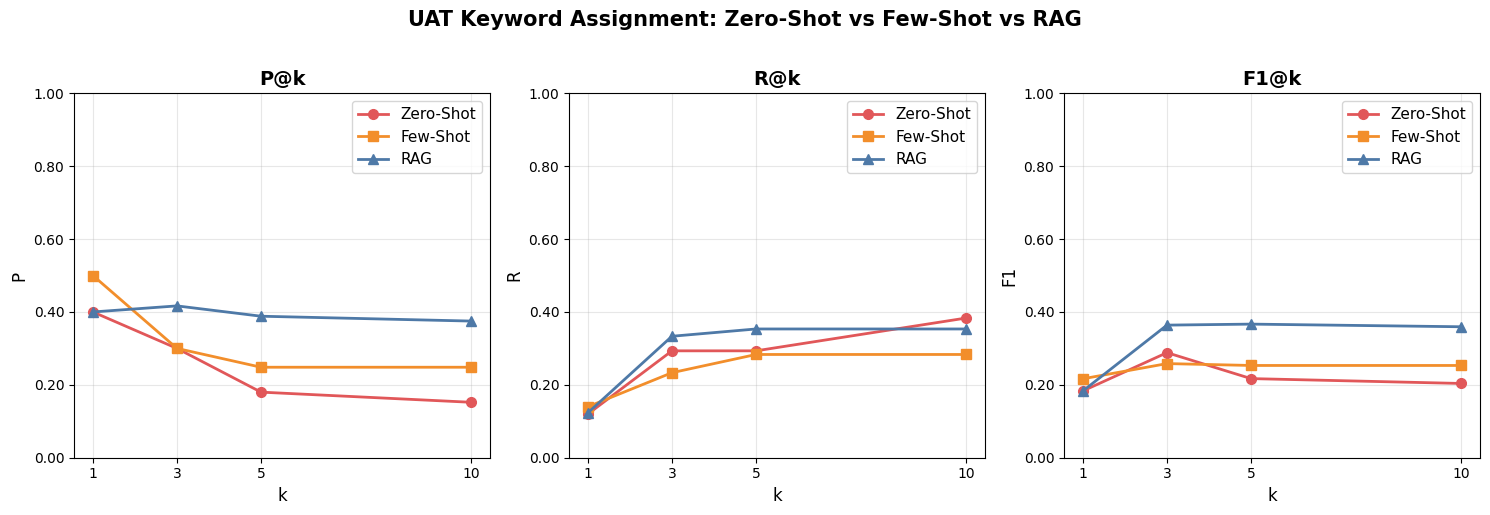

In [29]:
# Plot P@k, R@k, F1@k curves for each approach
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'Zero-Shot': '#e15759', 'Few-Shot': '#f28e2b', 'RAG': '#4e79a7'}
markers = {'Zero-Shot': 'o', 'Few-Shot': 's', 'RAG': '^'}

for ax, metric in zip(axes, ['P', 'R', 'F1']):
    for approach, results in approaches.items():
        values = [results[f'{metric}@{k}'] for k in ks]
        ax.plot(ks, values,
                label=approach,
                color=colors[approach],
                marker=markers[approach],
                linewidth=2,
                markersize=7)
    ax.set_title(f'{metric}@k', fontsize=14, fontweight='bold')
    ax.set_xlabel('k', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(ks)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.suptitle('UAT Keyword Assignment: Zero-Shot vs Few-Shot vs RAG',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('uat_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Summary & Takeaways

| Approach | Key idea | Strength | Weakness |
|---|---|---|---|
| **Zero-Shot** | No examples, pure LLM knowledge | Fast, no data needed | May not know UAT vocabulary |
| **Few-Shot** | Fixed examples in prompt | Simple, no infrastructure | Same examples for all queries |
| **RAG** | Dynamic retrieval of similar examples | Personalized context per query | Requires vector store setup |

**Key insight:** RAG essentially performs *dynamic few-shot*